In [28]:
import pandas as pd,numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split

In [29]:
df = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  "mosapabdelghany/medical-insurance-cost-dataset",
    "insurance.csv")

In [30]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [32]:
ndf = df.copy()

In [33]:
y = ndf.pop('charges')
x = ndf

In [34]:
y

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64

In [35]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

In [75]:
train = pd.concat([X_train,y_train],axis=1)

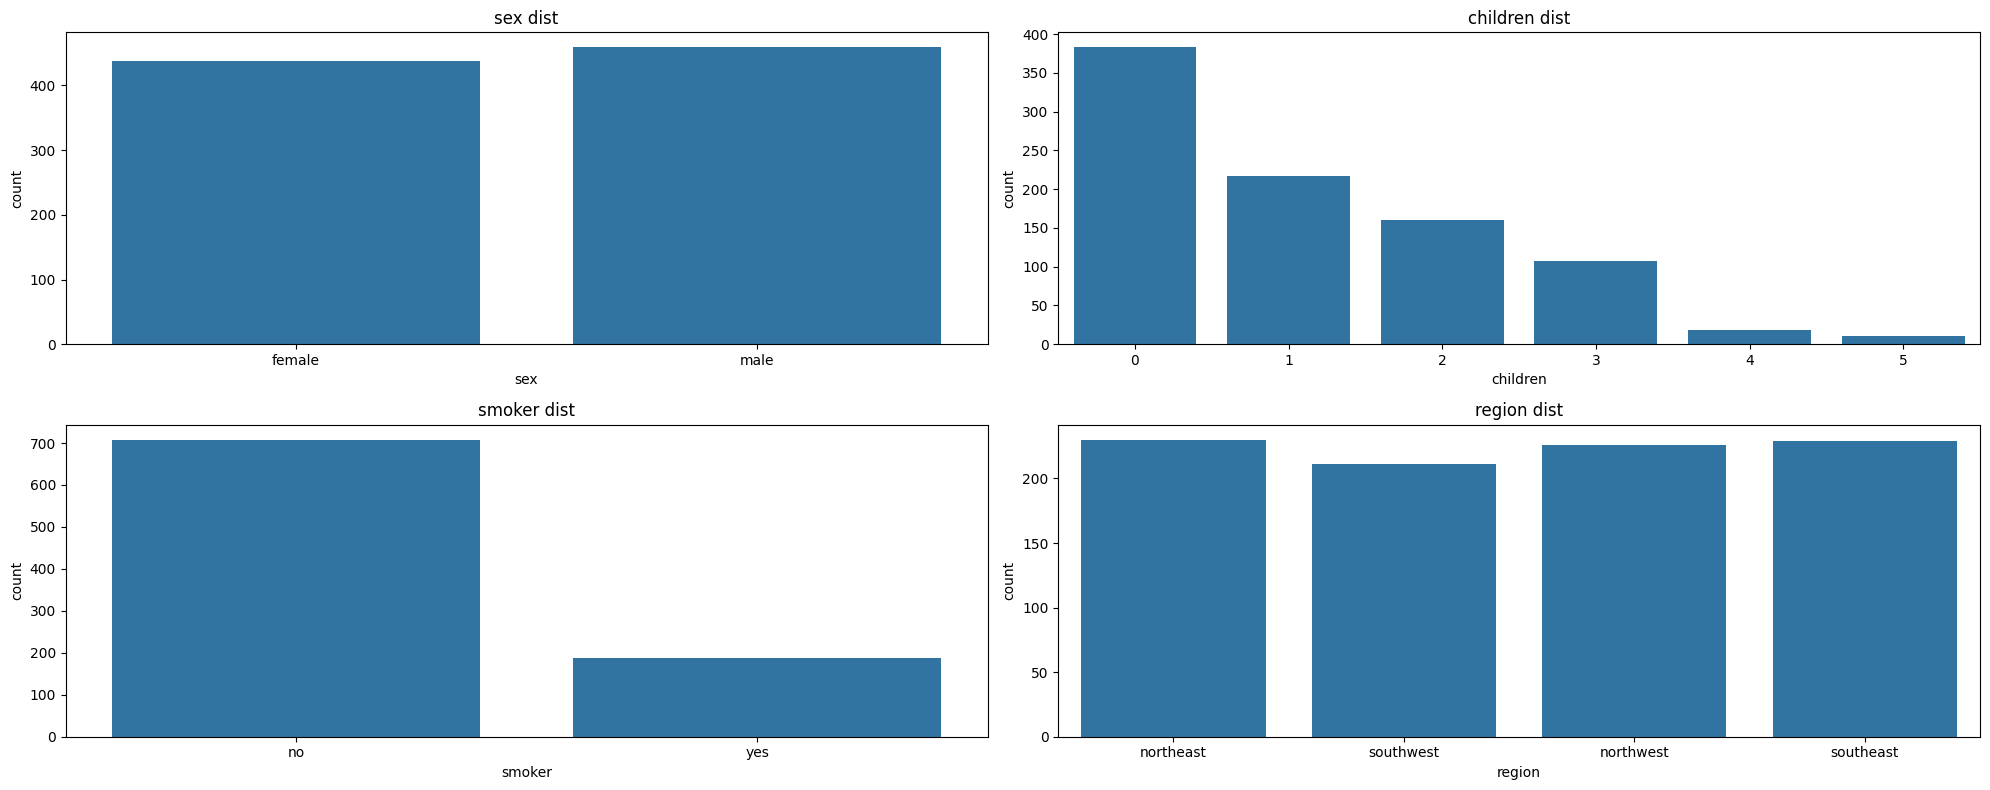

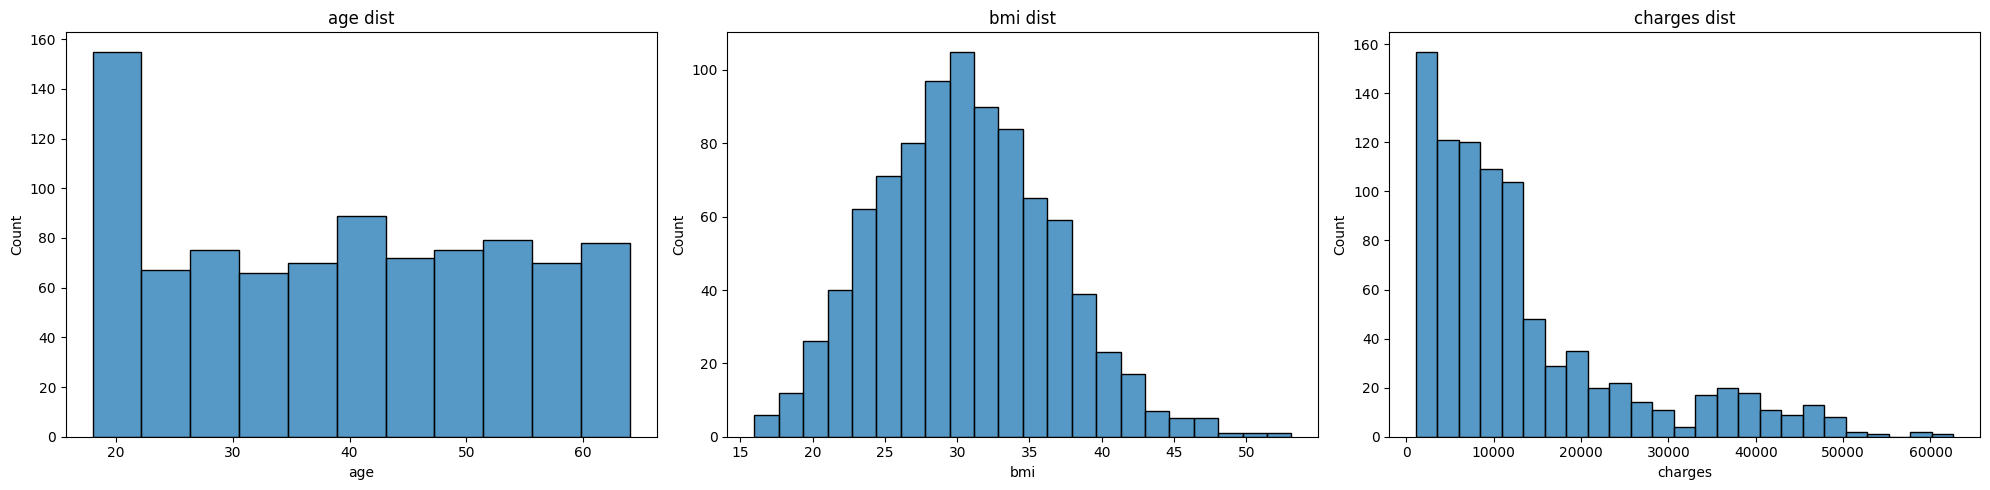

In [77]:
num_Cols = ['age','bmi','charges']
countCols = ['sex','children','smoker','region']
fig, axes = plt.subplots(2,2,figsize=(20,8))
ax= axes.flatten()
for i in range(len(countCols)):
    sns.countplot(x=train[countCols[i]],ax=ax[i]).set_title(f"{countCols[i]} dist")
plt.tight_layout()
plt.show

fig1,axes1 = plt.subplots(1,3,figsize=(20,5))
ax1 = axes1.flatten()
for x in range(len(num_Cols)):
     sns.histplot(train[num_Cols[x]],ax=ax1[x]).set_title(f"{num_Cols[x]} dist")
plt.tight_layout()
plt.show()    

In [76]:
train.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.108499,0.068628,0.287883
bmi,0.108499,1.000000,-0.000782,0.186289
children,0.068628,-0.000782,1.000000,0.084707
charges,0.287883,0.186289,0.084707,1.000000


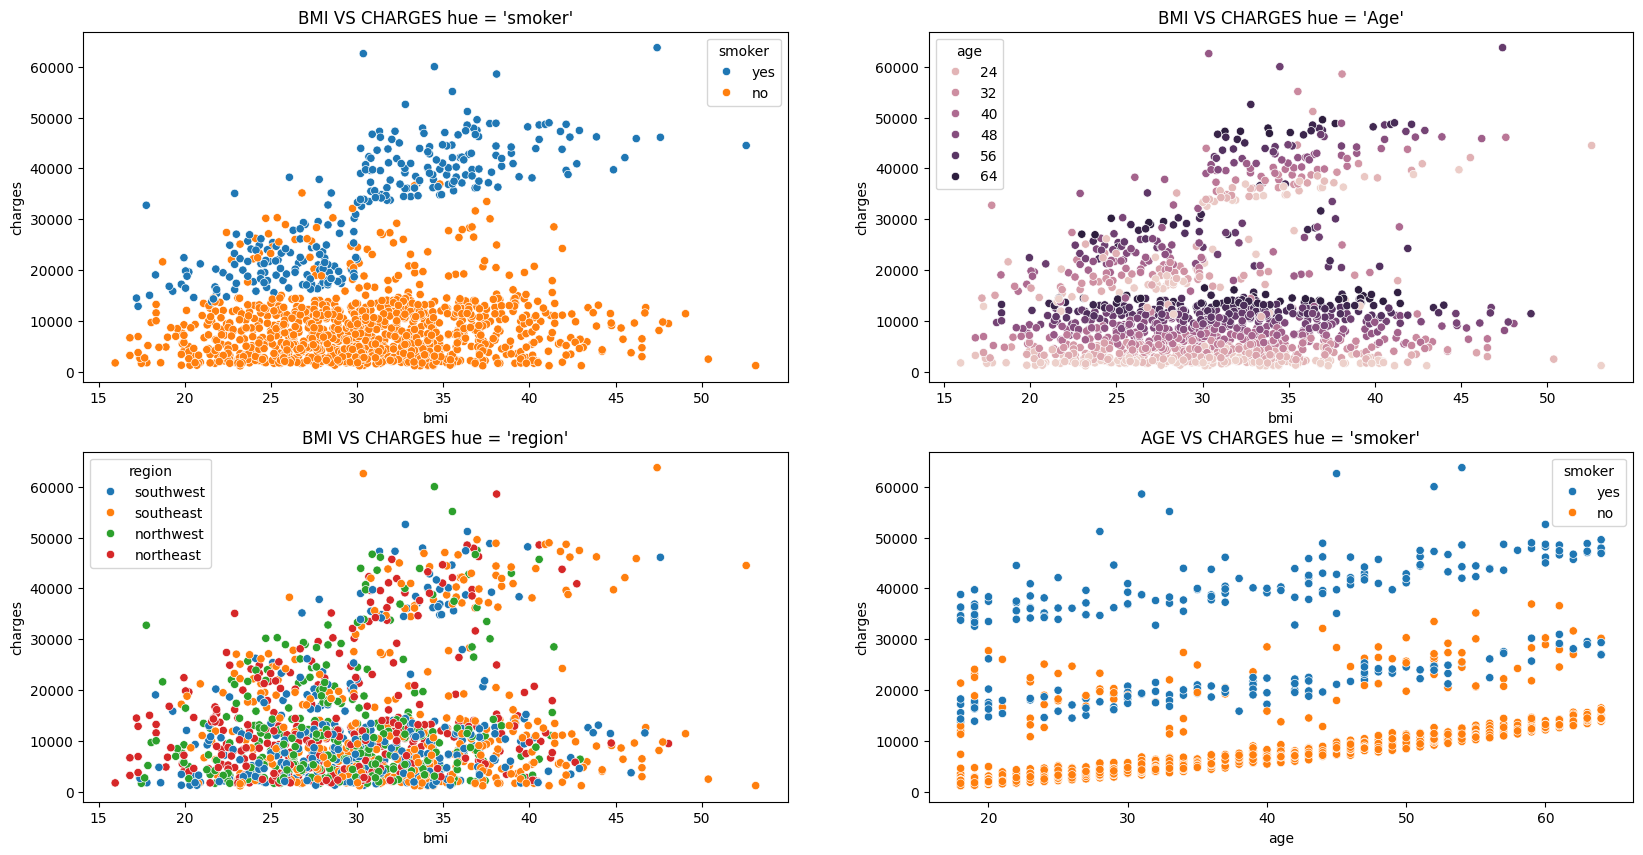

In [72]:
fig,axes = plt.subplots(2,2,figsize=(20,10))
ax=axes.flatten()
sns.scatterplot(train,x='bmi',y='charges',hue='smoker',ax=ax[0]).set_title("BMI VS CHARGES hue = 'smoker'")
sns.scatterplot(train,x='bmi',y='charges',hue='age',ax=ax[1]).set_title("BMI VS CHARGES hue = 'Age'")
sns.scatterplot(train,x='bmi',y='charges',hue='region',ax=ax[2]).set_title("BMI VS CHARGES hue = 'region'")
sns.scatterplot(train,x='age',y='charges',hue='smoker',ax=ax[3]).set_title("AGE VS CHARGES hue = 'smoker'")


plt.show()

In [86]:
pt = pd.pivot_table(train,index='region',columns='smoker',values='charges',aggfunc='mean').reset_index()

<Axes: xlabel='region'>

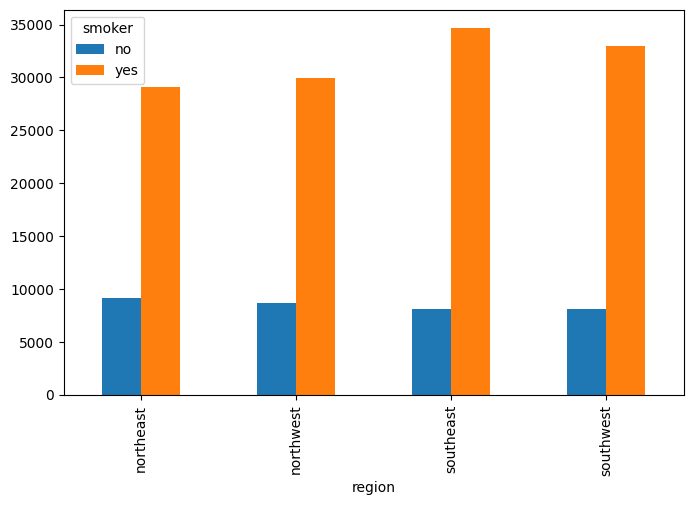

In [91]:
pt.plot(kind='bar',x='region', figsize=(8,5))

In [38]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler

In [48]:
numCols = ['age','bmi']
oheCols = ['region']
ordinalCols = ['smoker','sex']
ordinalLabels =  [['no','yes'],['female','male']]


In [54]:
transformer = ColumnTransformer(transformers=[
     ('scaler',StandardScaler(),numCols),
    ('ohe',OneHotEncoder(drop='first',sparse_output=False),oheCols),
    ('ordinal',OrdinalEncoder(categories=ordinalLabels),ordinalCols)
])

In [56]:
Pipe = Pipeline([
    ('tsf',transformer),
])

In [60]:
X_train_tsfed = Pipe.fit_transform(X_train)
X_test_tsfed = Pipe.transform(X_test)

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

In [92]:
lr = LinearRegression()
rf= RandomForestRegressor(random_state=42,n_jobs=-1)
dt = DecisionTreeRegressor(random_state=42)
knn = KNeighborsRegressor()

In [93]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [95]:
def model_n_card(model,X_train,X_test,y_train,y_test):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print("MAE score: ",mean_absolute_error(y_test,y_pred))
    print("MSE score: ",mean_squared_error(y_test,y_pred))
    print("train r2 score: ",model.score(X_train,y_train))
    print("test r2 score: ",model.score(X_test,y_test))
    return model

In [98]:
lr_fitted = model_n_card(lr,X_train_tsfed,X_test_tsfed,y_train,y_test)

MAE score:  4233.420414468101
MSE score:  35625634.55694166
train r2 score:  0.7442560970103775
test r2 score:  0.7568957098073767


In [99]:
rf_fitted = model_n_card(rf,X_train_tsfed,X_test_tsfed,y_train,y_test)

MAE score:  2926.346538621752
MSE score:  25799918.41381405
train r2 score:  0.9753109354109061
test r2 score:  0.823945006705972


In [100]:
dt_fitted = model_n_card(dt,X_train_tsfed,X_test_tsfed,y_train,y_test)

MAE score:  3546.653974613122
MSE score:  48261540.53820408
train r2 score:  0.9999973571769957
test r2 score:  0.6706700750160668


In [101]:
knn_fitted = model_n_card(knn,X_train_tsfed,X_test_tsfed,y_train,y_test)

MAE score:  3653.677602169683
MSE score:  37150704.17054948
train r2 score:  0.845585497568777
test r2 score:  0.746488850518516


In [109]:
rf = RandomForestRegressor(max_features=0.8,random_state=42,n_jobs=-1)
model_n_card(rf,X_train_tsfed,X_test_tsfed,y_train,y_test)

MAE score:  2863.748729951207
MSE score:  25018668.861729395
train r2 score:  0.976489992504534
test r2 score:  0.8292761431245889


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",0.8
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [120]:
from sklearn.model_selection import cross_val_score

In [111]:
cvs = cross_val_score(rf,X_train_tsfed,y_train,cv=10,n_jobs=-1)

In [115]:
print(f"mean: {cvs.mean()}, std: {cvs.std()}, max: {cvs.max()}")

mean: 0.8262524932837702, std: 0.042475107465087016, max: 0.9254623125352092


In [116]:
import joblib

In [117]:
rf_pipe = Pipeline([
    ('tsf',transformer),
    ('rf',RandomForestRegressor(max_features=0.8,random_state=42,n_jobs=-1))
])

In [121]:
rf_pipe.fit(X_train,y_train)
rf_pipe.score(X_test,y_test)

0.8292761431245889

In [124]:
joblib.dump(rf_pipe,'Insurance_rf_pipeline.joblib')

['Insurance_rf_pipeline.joblib']